<a href="https://colab.research.google.com/github/Essohanam-lab-art/Interactive-quiz-analytics/blob/main/exo_projet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv('/content/dataset_planification_transport_LK.csv')
df

,trajet_id,ville_depart,ville_arrivee,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,type_bus,jour_semaine,periode_depart,condition_route,carburant_litre,satisfaction_client
0,1,Tsévié,Tsévié,56.0,7.2,163.0,8847.0,52.0,50.0,Climatisé,Dimanche,Après-midi,Bonne,43.4,3
1,2,Sokodé,Tsévié,NaN,2.9,124.0,9401.0,39.0,NaN,Standard,Dimanche,NaN,Moyenne,73.7,4
2,3,Dapaong,Sokodé,496.0,1.6,163.0,9228.0,56.0,NaN,Standard,Dimanche,Soir,Bonne,26.5,2
3,4,Sokodé,Lomé,463.0,8.8,88.0,3618.0,NaN,NaN,VIP,Jeudi,Matin,Mauvaise,42.5,4
4,5,Kara,Dapaong,130.0,3.4,32.0,7518.0,67.0,50.0,VIP,Dimanche,Après-midi,Mauvaise,21.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,Lomé,NaN,428.0,9.1,137.0,1851.0,33.0,50.0,Standard,Lundi,Matin,Moyenne,38.2,4
1996,1997,Tsévié,Tsévié,406.0,NaN,NaN,6832.0,68.0,70.0,Standard,Dimanche,Après-midi,Moyenne,62.7,3
1997,1998,Atakpamé,Sokodé,615.0,2.2,28.0,3754.0,9.0,50.0,Standard,Vendredi,Soir,NaN,46.0,1
1998,1999,Tsévié,Tsévié,428.0,11.7,0.0,4182.0,14.0,30.0,Climatisé,Lundi,Matin,Bonne,18.7,4


In [ ]:
df.isnull().sum()

,0
trajet_id,0
ville_depart,156
ville_arrivee,160
distance_km,160
duree_prevue_h,160
retard_min,160
prix_billet,160
nb_passagers,164
capacite_bus,160
type_bus,160


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   trajet_id            2000 non-null   int64  
 1   ville_depart         1844 non-null   object 
 2   ville_arrivee        1840 non-null   object 
 3   distance_km          1840 non-null   float64
 4   duree_prevue_h       1840 non-null   float64
 5   retard_min           1840 non-null   float64
 6   prix_billet          1840 non-null   float64
 7   nb_passagers         1836 non-null   float64
 8   capacite_bus         1840 non-null   float64
 9   type_bus             1840 non-null   object 
 10  jour_semaine         1840 non-null   object 
 11  periode_depart       1840 non-null   object 
 12  condition_route      1840 non-null   object 
 13  carburant_litre      1840 non-null   float64
 14  satisfaction_client  2000 non-null   int64  
dtypes: float64(7), int64(2), object(6)
mem

In [ ]:
df.dropna()

,trajet_id,ville_depart,ville_arrivee,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,type_bus,jour_semaine,periode_depart,condition_route,carburant_litre,satisfaction_client
0,1,Tsévié,Tsévié,56.0,7.2,163.0,8847.0,52.0,50.0,Climatisé,Dimanche,Après-midi,Bonne,43.4,3
4,5,Kara,Dapaong,130.0,3.4,32.0,7518.0,67.0,50.0,VIP,Dimanche,Après-midi,Mauvaise,21.5,1
5,6,Atakpamé,Dapaong,643.0,7.7,172.0,3194.0,26.0,30.0,Standard,Samedi,Soir,Bonne,46.1,1
6,7,Sokodé,Atakpamé,491.0,6.4,143.0,4272.0,43.0,40.0,Standard,Samedi,Soir,Bonne,63.0,5
9,10,Kara,Atakpamé,345.0,7.0,167.0,8811.0,29.0,30.0,Standard,Mercredi,Soir,Bonne,32.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1988,1989,Atakpamé,Kara,167.0,6.4,39.0,7817.0,50.0,60.0,VIP,Dimanche,Après-midi,Bonne,52.3,1
1989,1990,Kara,Atakpamé,430.0,11.4,107.0,11082.0,44.0,50.0,Climatisé,Dimanche,Matin,Bonne,70.2,3
1992,1993,Kara,Dapaong,285.0,2.8,121.0,11242.0,11.0,30.0,VIP,Mercredi,Matin,Moyenne,74.1,3
1998,1999,Tsévié,Tsévié,428.0,11.7,0.0,4182.0,14.0,30.0,Climatisé,Lundi,Matin,Bonne,18.7,4


In [ ]:
df.isnull().sum()

,0
trajet_id,0
ville_depart,156
ville_arrivee,160
distance_km,160
duree_prevue_h,160
retard_min,160
prix_billet,160
nb_passagers,164
capacite_bus,160
type_bus,160


In [ ]:
df.describe()

,trajet_id,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,carburant_litre,satisfaction_client
count,2000.000000,1840.000000,1840.000000,1840.000000,1840.000000,1836.000000,1840.000000,1840.000000,2000.00000
mean,1000.500000,352.983696,6.775326,91.687500,6726.460326,37.994009,50.315217,47.511196,2.99750
std,577.494589,173.609929,2.975420,51.889587,3071.395956,19.120825,13.968371,18.564397,1.39695
min,1.000000,50.000000,1.500000,0.000000,1528.000000,5.000000,30.000000,15.000000,1.00000
25%,500.750000,203.000000,4.200000,48.000000,4008.000000,21.000000,40.000000,31.575000,2.00000
50%,1000.500000,355.000000,6.900000,93.000000,6599.000000,39.000000,50.000000,47.350000,3.00000
75%,1500.250000,503.000000,9.300000,137.000000,9527.000000,54.000000,60.000000,63.500000,4.00000
max,2000.000000,649.000000,12.000000,179.000000,11997.000000,79.000000,70.000000,80.000000,5.00000


In [ ]:
df.describe(include='object')

,ville_depart,ville_arrivee,type_bus,jour_semaine,periode_depart,condition_route
count,1844,1840,1840,1840,1840,1840
unique,6,6,3,7,3,3
top,Atakpamé,Sokodé,VIP,Mercredi,Soir,Mauvaise
freq,327,330,641,289,635,634


In [ ]:
#determiner les outliers.. ici on n'utilise pas le Q2 car ca va se centrer sur un point tandis que IQR(intervalle interquantile) nous donne un intervalle
colunm_num = df.select_dtypes(include='number').columns
for i in colunm_num:
  Q1 =df[i].quantile(0.25)
  Q3 =df[i].quantile(0.75)
  IQR = Q3-Q1
  lower_bound = Q1-1.5*IQR
  upper_bound = Q3+1.5*IQR
  outliers = df[(df[i]<lower_bound) | (df[i]>upper_bound)]#| est ou
  print(f"les outliers de la colonne {i} sont :{len(outliers)}")


les outliers de la colonne trajet_id sont :0
les outliers de la colonne distance_km sont :0
les outliers de la colonne duree_prevue_h sont :0
les outliers de la colonne retard_min sont :0
les outliers de la colonne prix_billet sont :0
les outliers de la colonne nb_passagers sont :0
les outliers de la colonne capacite_bus sont :0
les outliers de la colonne carburant_litre sont :0
les outliers de la colonne satisfaction_client sont :0


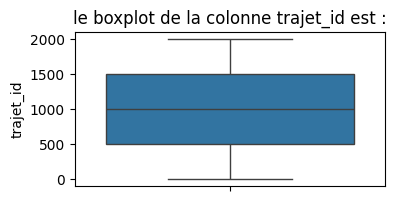

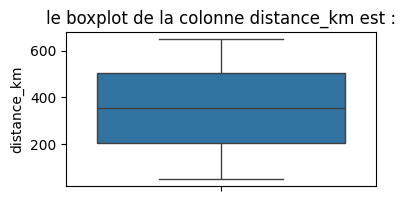

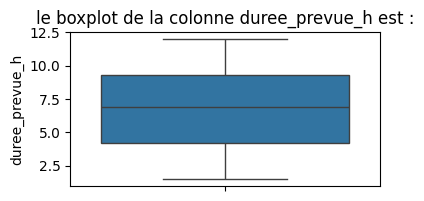

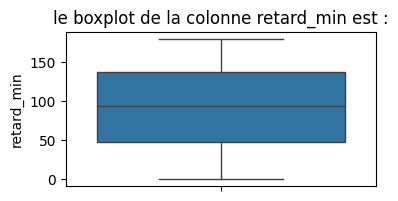

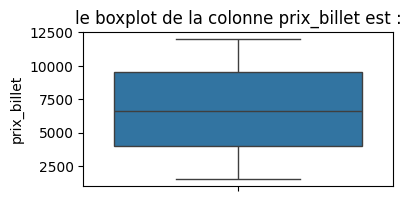

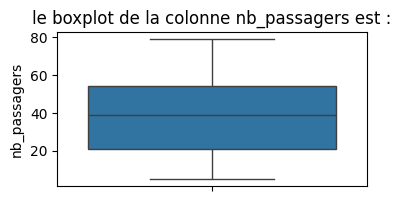

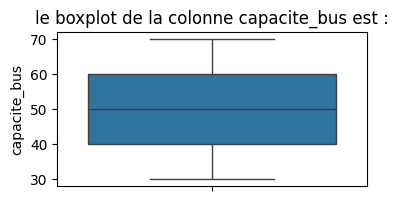

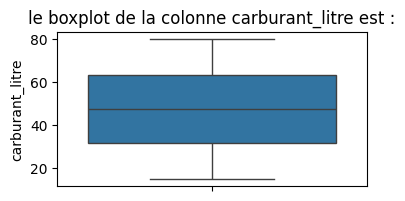

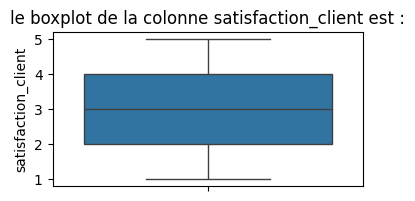

In [ ]:
for i in colunm_num:
  plt.figure(figsize=(4,2))
  sns.boxplot(df[i])
  plt.title(f"le boxplot de la colonne {i} est :")
  plt.show()

In [ ]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))])
categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [ ]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
     ("scaler", StandardScaler())])
numeric_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [ ]:
from sklearn.compose import ColumnTransformer
num_col = ["trajet_id",	"distance_km",	"duree_prevue_h",	"retard_min",	"prix_billet",	"nb_passagers",	"capacite_bus",	"carburant_litre",	"satisfaction_client"]
cat_col = ["ville_depart",	"ville_arrivee",	"type_bus",	"jour_semaine",	"periode_depart",	"condition_route"]
preprocess = ColumnTransformer(
    transformers=[("num", numeric_pipeline, num_col),
     ("cat", categorical_pipeline, cat_col)])
preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['trajet_id', 'distance_km', 'duree_prevue_h',
                                  'retard_min', 'prix_billet', 'nb_passagers',
                                  'capacite_bus', 'carburant_litre',
                                  'satisfaction_client']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ville_depart', 'ville_arrivee', 'type_bus',
                                  'jour_semaine', 'periode_depart',
                                  'condition_route'])])

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop("satisfaction_client", axis=1)
y = df["satisfaction_client"]


In [ ]:
X_train , X_test, y_train, y_test = train_test_split(X,y, random_state = 42,
                                                     test_size = 0.2)

In [ ]:
#Taux de remplissage = Nombre de passagers\Capaciteˊ totale du bus
#Retard/km = Retard total (minutes)\Distance parcourue (km)
#Retard/h = Retard total (minutes)\Dureˊe preˊvue (heures)
#Passagers/km = Nombre de passagers\Distance parcourue
#Couˆt/passager = Couˆt total du trajet\Nombre de passagers
#Couˆt/km = Couˆt total du trajet\Distance parcourue

#display(df['retard_min'].describe())
df['taux_remplissage'] = df['nb_passagers'] / df['capacite_bus']
df['retard_par_km'] = df['retard_min'] / df['distance_km']
df['retard_par_h'] = df['retard_min'] / df['duree_prevue_h']
df['passagers_par_km'] = df['nb_passagers'] / df['distance_km']
df

,trajet_id,ville_depart,ville_arrivee,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,type_bus,jour_semaine,periode_depart,condition_route,carburant_litre,satisfaction_client,taux_remplissage,retard_par_km,retard_par_h,passagers_par_km
0,1,Tsévié,Tsévié,56.0,7.2,163.0,8847.0,52.0,50.0,Climatisé,Dimanche,Après-midi,Bonne,43.4,3,1.040000,2.910714,22.638889,0.928571
1,2,Sokodé,Tsévié,NaN,2.9,124.0,9401.0,39.0,NaN,Standard,Dimanche,NaN,Moyenne,73.7,4,NaN,NaN,42.758621,NaN
2,3,Dapaong,Sokodé,496.0,1.6,163.0,9228.0,56.0,NaN,Standard,Dimanche,Soir,Bonne,26.5,2,NaN,0.328629,101.875000,0.112903
3,4,Sokodé,Lomé,463.0,8.8,88.0,3618.0,NaN,NaN,VIP,Jeudi,Matin,Mauvaise,42.5,4,NaN,0.190065,10.000000,NaN
4,5,Kara,Dapaong,130.0,3.4,32.0,7518.0,67.0,50.0,VIP,Dimanche,Après-midi,Mauvaise,21.5,1,1.340000,0.246154,9.411765,0.515385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,Lomé,NaN,428.0,9.1,137.0,1851.0,33.0,50.0,Standard,Lundi,Matin,Moyenne,38.2,4,0.660000,0.320093,15.054945,0.077103
1996,1997,Tsévié,Tsévié,406.0,NaN,NaN,6832.0,68.0,70.0,Standard,Dimanche,Après-midi,Moyenne,62.7,3,0.971429,NaN,NaN,0.167488
1997,1998,Atakpamé,Sokodé,615.0,2.2,28.0,3754.0,9.0,50.0,Standard,Vendredi,Soir,NaN,46.0,1,0.180000,0.045528,12.727273,0.014634
1998,1999,Tsévié,Tsévié,428.0,11.7,0.0,4182.0,14.0,30.0,Climatisé,Lundi,Matin,Bonne,18.7,4,0.466667,0.000000,0.000000,0.032710


In [ ]:
display(df['retard_min'].describe())

,retard_min
count,1840.000000
mean,91.687500
std,51.889587
min,0.000000
25%,48.000000
50%,93.000000
75%,137.000000
max,179.000000


In [ ]:
display(df['taux_remplissage'].describe())

,taux_remplissage
count,1697.000000
mean,0.822327
std,0.491066
min,0.071429
25%,0.428571
50%,0.771429
75%,1.128571
max,2.300000


In [ ]:
display(df['passagers_par_km'].describe())

,passagers_par_km
count,1693.000000
mean,0.159836
std,0.168942
min,0.007752
25%,0.061404
50%,0.106691
75%,0.188366
max,1.160000


In [ ]:
from sklearn.compose import ColumnTransformer
num_col = ['trajet_id', 'distance_km', 'duree_prevue_h', 'retard_min', 'prix_billet', 'nb_passagers',
           'capacite_bus', 'carburant_litre', 'taux_remplissage', 'retard_par_km',
           'retard_par_h', 'passagers_par_km']
cat_col = ['ville_depart', 'ville_arrivee', 'type_bus', 'jour_semaine', 'periode_depart', 'condition_route']
preprocess = ColumnTransformer(
    transformers=[("num", numeric_pipeline, num_col),
     ("cat", categorical_pipeline, cat_col)])
preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['trajet_id', 'distance_km', 'duree_prevue_h',
                                  'retard_min', 'prix_billet', 'nb_passagers',
                                  'capacite_bus', 'carburant_litre',
                                  'taux_remplissage', 'retard_par_km',
                                  'retard_par_h', 'passagers_par_km']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ville_depart', 'ville_arrivee', 'type_bus',
                                  'jour_semaine', 'periode_depart',
                                  'condition_route'])])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # Changed from LinearRegression to a classifier
from sklearn.pipeline import Pipeline

# Define X and y from the df with engineered features (ensuring df is up-to-date)
X = df.drop("satisfaction_client", axis=1)
y = df["satisfaction_client"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# Handle NaNs in y_train and corresponding X_train
# Create a mask for non-null values in y_train
non_null_y_train_mask = y_train.notna()

# Filter X_train and y_train
X_train_filtered = X_train[non_null_y_train_mask]
y_train_filtered = y_train[non_null_y_train_mask]

# For X_test and y_test, also filter out NaNs for a clean evaluation
non_null_y_test_mask = y_test.notna()
X_test_filtered = X_test[non_null_y_test_mask]
y_test_filtered = y_test[non_null_y_test_mask]

# Define the full machine learning pipeline
# This pipeline first applies the preprocessing steps defined in 'preprocess'
# and then fits a RandomForestClassifier model.
full_pipeline = Pipeline(steps=[('preprocessor', preprocess),
                                ('classifier', RandomForestClassifier(random_state=42))])

# Fit the pipeline using the filtered training data
full_pipeline.fit(X_train_filtered, y_train_filtered)

# Make predictions on the filtered test data
y_pred = full_pipeline.predict(X_test_filtered)

print("Résultat de la prédiction :", y_pred)
print("Données réelles :", y_test_filtered)

Résultat de la prédiction : [5 3 3 3 3 2 3 5 5 2 1 3 3 2 4 3 3 4 3 1 4 3 3 2 4 4 3 3 3 2 4 4 3 4 1 2 4
 3 1 1 2 3 5 3 3 3 3 1 4 3 3 1 3 3 3 2 2 3 2 3 3 1 4 4 3 2 3 4 1 3 2 4 3 3
 1 4 3 3 4 4 1 1 3 2 3 5 3 3 3 3 2 3 2 3 3 3 3 5 1 5 5 5 2 1 5 4 3 1 2 3 4
 1 4 3 5 1 1 3 4 3 3 3 5 4 1 2 1 3 2 3 3 3 4 1 1 3 4 3 5 3 3 3 5 4 5 1 3 3
 3 5 3 3 5 4 1 5 2 3 1 3 4 3 3 4 3 3 2 2 1 5 3 3 2 2 4 5 2 5 2 1 2 4 3 4 1
 2 3 1 1 4 1 5 2 2 2 3 3 1 4 3 1 5 5 4 5 4 3 2 1 3 1 1 4 4 1 1 3 1 2 3 5 3
 5 4 2 3 4 3 2 2 3 1 2 2 3 3 3 5 3 5 2 1 2 3 3 4 3 1 4 4 3 5 1 1 1 5 4 2 3
 5 5 5 3 5 2 1 1 5 2 1 3 3 3 2 3 3 2 3 2 3 4 2 5 4 3 3 3 5 4 4 5 3 1 3 2 3
 4 5 3 4 3 3 1 3 3 2 3 4 3 4 2 4 2 5 1 4 3 1 1 4 3 5 2 2 5 3 3 3 2 3 3 2 3
 5 4 2 3 4 2 1 4 5 1 4 1 3 1 3 5 3 3 3 5 5 3 3 3 1 2 4 1 3 1 4 3 1 5 3 4 1
 3 3 2 3 2 1 2 5 1 1 4 3 3 1 3 3 3 2 2 4 2 3 3 2 2 5 3 5 1 1]
Données réelles : 1860    5
353     3
1333    5
905     5
1289    5
       ..
965     3
1284    3
1739    2
261     5
535     3
Name: satisfaction_client, Lengt

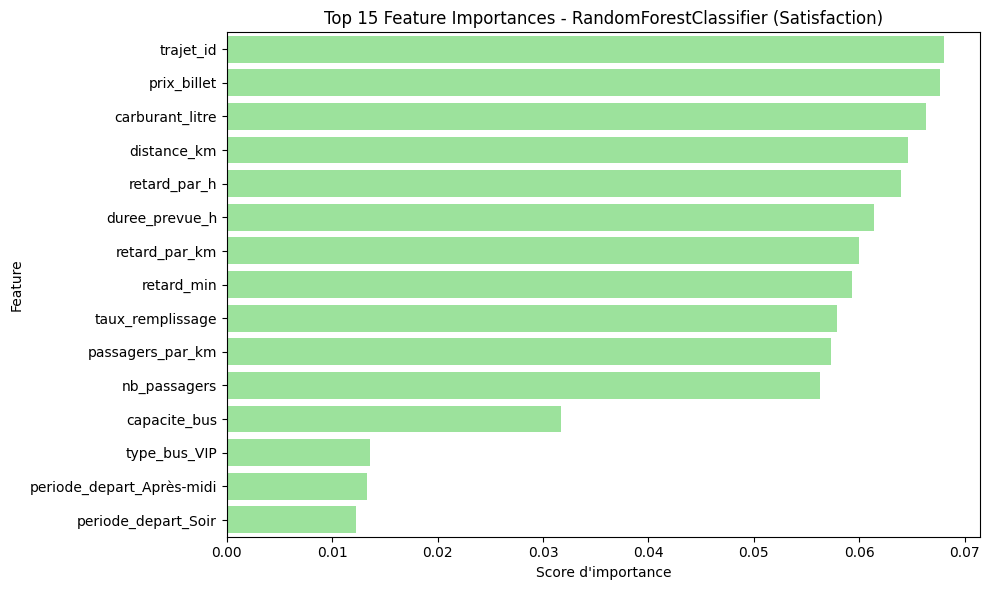

In [ ]:
importances = full_pipeline.named_steps['classifier'].feature_importances_

# Get feature names after preprocessing
preprocessor = full_pipeline.named_steps['preprocessor']

# Get numerical feature names (original)
num_features = preprocessor.named_transformers_['num'].feature_names_in_

# Get categorical feature names (one-hot encoded)
cat_transformer = preprocessor.named_transformers_['cat']
cat_features = cat_transformer.get_feature_names_out(preprocessor.transformers_[1][2]) # Use original cat column names

# Combine all feature names
features = list(num_features) + list(cat_features)

# Create a DataFrame for better visualization and sorting
feature_importance_df = pd.DataFrame({'feature': features, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), color='lightgreen') # Display top 15 features
plt.title("Top 15 Feature Importances - RandomForestClassifier (Satisfaction)")
plt.xlabel("Score d'importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
df['trajet_risque'] = ( (df['retard_min'] > 10) |
(df['taux_remplissage'] > 0.9)
).astype(int)
df
#X = df[['taux_remplissage','retard_par_km',]]
#y = df['trajet_risque']

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#clf = RandomForestClassifier(random_state=42)
#clf.fit(X_train, y_train)

#y_pred = clf.predict(X_test)

#print("\n=== Classification (Trajet à risque) ===")
#print(classification_report(y_test, y_pred))
#print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))

,trajet_id,ville_depart,ville_arrivee,distance_km,duree_prevue_h,retard_min,prix_billet,nb_passagers,capacite_bus,type_bus,jour_semaine,periode_depart,condition_route,carburant_litre,satisfaction_client,taux_remplissage,retard_par_km,retard_par_h,passagers_par_km,trajet_risque
0,1,Tsévié,Tsévié,56.0,7.2,163.0,8847.0,52.0,50.0,Climatisé,Dimanche,Après-midi,Bonne,43.4,3,1.040000,2.910714,22.638889,0.928571,1
1,2,Sokodé,Tsévié,NaN,2.9,124.0,9401.0,39.0,NaN,Standard,Dimanche,NaN,Moyenne,73.7,4,NaN,NaN,42.758621,NaN,1
2,3,Dapaong,Sokodé,496.0,1.6,163.0,9228.0,56.0,NaN,Standard,Dimanche,Soir,Bonne,26.5,2,NaN,0.328629,101.875000,0.112903,1
3,4,Sokodé,Lomé,463.0,8.8,88.0,3618.0,NaN,NaN,VIP,Jeudi,Matin,Mauvaise,42.5,4,NaN,0.190065,10.000000,NaN,1
4,5,Kara,Dapaong,130.0,3.4,32.0,7518.0,67.0,50.0,VIP,Dimanche,Après-midi,Mauvaise,21.5,1,1.340000,0.246154,9.411765,0.515385,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,Lomé,NaN,428.0,9.1,137.0,1851.0,33.0,50.0,Standard,Lundi,Matin,Moyenne,38.2,4,0.660000,0.320093,15.054945,0.077103,1
1996,1997,Tsévié,Tsévié,406.0,NaN,NaN,6832.0,68.0,70.0,Standard,Dimanche,Après-midi,Moyenne,62.7,3,0.971429,NaN,NaN,0.167488,1
1997,1998,Atakpamé,Sokodé,615.0,2.2,28.0,3754.0,9.0,50.0,Standard,Vendredi,Soir,NaN,46.0,1,0.180000,0.045528,12.727273,0.014634,1
1998,1999,Tsévié,Tsévié,428.0,11.7,0.0,4182.0,14.0,30.0,Climatisé,Lundi,Matin,Bonne,18.7,4,0.466667,0.000000,0.000000,0.032710,0


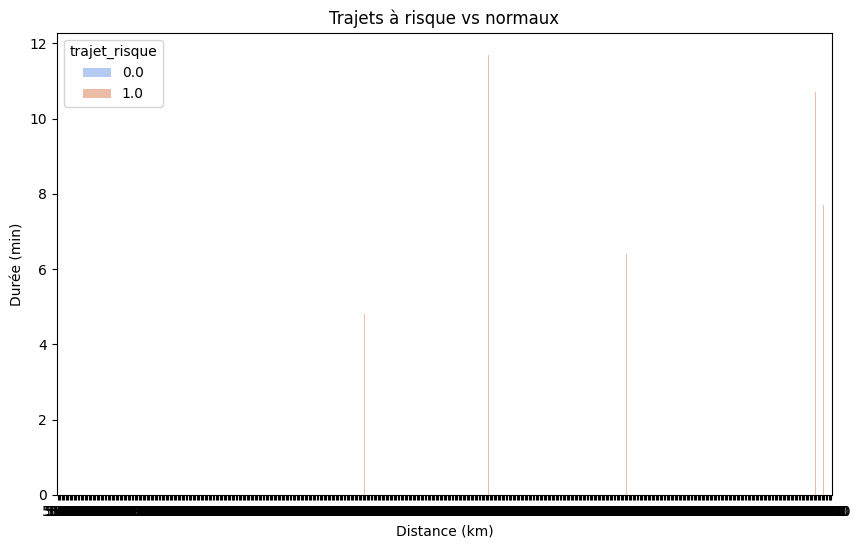

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=df["distance_km"], y=df["duree_prevue_h"], hue=df["trajet_risque"].head(15), palette="coolwarm")
plt.xlabel("Distance (km)")
plt.ylabel("Durée (min)")
plt.title("Trajets à risque vs normaux")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier#, RandomForestRegressor # Added RandomForestRegressor

X = df[["distance_km","duree_prevue_h"]]
y = df["trajet_risque"]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Classification binaire ---
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred_class = clf.predict(X_test)

print("Classification (0=normal, 1=risqué):", y_pred_class)

# --- Régression (score de risque continu) ---
#reg = RandomForestRegressor(random_state=42)
#reg.fit(X_train, y_train)
#y_pred_score = reg.predict(X_test)

#print("Score de risque (entre 0 et 1):", y_pred_score)

Classification (0=normal, 1=risqué): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # Changed from LinearRegression to a classifier
from sklearn.pipeline import Pipeline

# Define X and y from the df with engineered features (ensuring df is up-to-date)
X = df.drop("trajet_risque", axis=1)
y = df["trajet_risque"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# Handle NaNs in y_train and corresponding X_train
# Create a mask for non-null values in y_train
non_null_y_train_mask = y_train.notna()

# Filter X_train and y_train
X_train_filtered = X_train[non_null_y_train_mask]
y_train_filtered = y_train[non_null_y_train_mask]

# For X_test and y_test, also filter out NaNs for a clean evaluation
non_null_y_test_mask = y_test.notna()
X_test_filtered = X_test[non_null_y_test_mask]
y_test_filtered = y_test[non_null_y_test_mask]

# Define the full machine learning pipeline
# This pipeline first applies the preprocessing steps defined in 'preprocess'
# and then fits a RandomForestClassifier model.
full_pipeline = Pipeline(steps=[('preprocessor', preprocess),
                                ('classifier', RandomForestClassifier(random_state=42))])

# Fit the pipeline using the filtered training data
full_pipeline.fit(X_train_filtered, y_train_filtered)

# Make predictions on the filtered test data
y_pred = full_pipeline.predict(X_test_filtered)

print("Résultat de la prédiction :", y_pred)
print("Données réelles :", y_test_filtered)

Résultat de la prédiction : [1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1]
Données réelles : 1860    1
353     1
1333    1
905     1
1289    1
       ..
965     1
1284    1
1739    1
261     1
535     1
Name: trajet_risque, Length: 400

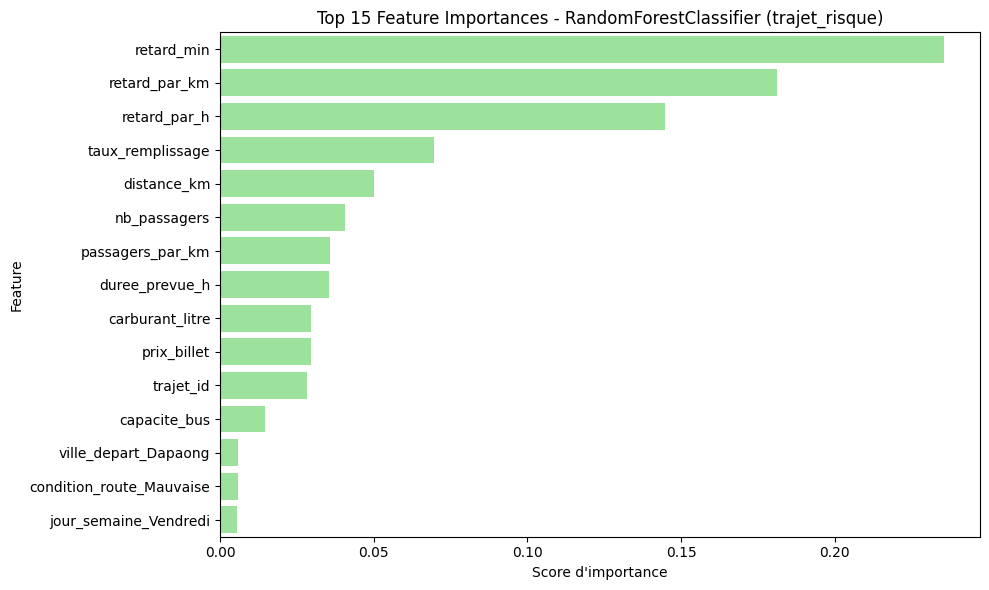

In [ ]:
importances = full_pipeline.named_steps['classifier'].feature_importances_

# Get feature names after preprocessing
preprocessor = full_pipeline.named_steps['preprocessor']

# Get numerical feature names (original)
num_features = preprocessor.named_transformers_['num'].feature_names_in_

# Get categorical feature names (one-hot encoded)
cat_transformer = preprocessor.named_transformers_['cat']
cat_features = cat_transformer.get_feature_names_out(preprocessor.transformers_[1][2]) # Use original cat column names

# Combine all feature names
features = list(num_features) + list(cat_features)

# Create a DataFrame for better visualization and sorting
feature_importance_df = pd.DataFrame({'feature': features, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(15), color='lightgreen') # Display top 15 features
plt.title("Top 15 Feature Importances - RandomForestClassifier (trajet_risque)")
plt.xlabel("Score d'importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()